In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MaxNLocator


Generic Stats

In [ ]:
#Season Averages Over The Years

df = pd.read_csv("game_stats_wide.csv")

#Filter out non-Indiana teams

df = df[df['team'] == 'Texas']

season_averages = df.groupby('year').mean(numeric_only=True).reset_index()

#Plot Points Over Time by Year

plt.plot(season_averages['year'], season_averages['points'])
ax = plt.gca()
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.xlabel('Year')
plt.ylabel('Average Points')
plt.title('Indiana Hoosiers Average Points Per Game Over the Years')
plt.show()

#Plot totalYards Over Time by Year

plt.plot(season_averages['year'], season_averages['totalYards'])
plt.xlabel('Year')
plt.ylabel('Average Total Yards')
plt.title('Indiana Hoosiers Average Total Yards Per Game Over the Years')
ax = plt.gca()
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

#Plot Pass Yards Per Attempt Over Time by Year

plt.plot(season_averages['year'], season_averages['yardsPerPass'])
plt.xlabel('Year')
plt.ylabel('Average Pass Yards Per Attempt')
plt.title('Indiana Hoosiers Average Pass Yards Per Attempt Over the Years')
ax = plt.gca()
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

#Plot Rush Yards Per Attempt Over Time by Year

plt.plot(season_averages['year'], season_averages['yardsPerRushAttempt'])
plt.xlabel('Year')
plt.ylabel('Average Rush Yards Per Attempt')
plt.title('Indiana Hoosiers Average Rush Yards Per Attempt Over the Years')
ax = plt.gca()
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

#Plot 3rd Down Efficiency Over Time by Year

plt.plot(season_averages['year'], season_averages['thirdDownEff'])
plt.xlabel('Year')
plt.ylabel('Average 3rd Down Efficiency')
plt.title('Indiana Hoosiers Average 3rd Down Efficiency Over the Years')
ax = plt.gca()
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.tight_layout()
plt.show()


In [ ]:
#Advanced Stats Over the Years

adv_df = pd.read_csv("indiana_adv.csv")

plt.figure(figsize=(12, 6))
plt.plot(adv_df['year'], adv_df['offense_standard_downs_success_rate'])
plt.xlabel('Year')
plt.ylabel('Offense Standard Downs Success Rate')
plt.title('Offense Standard Downs Success Rate Over the Years')
plt.show()

In [ ]:
#Advanced Stats: Against Other Teams
allteams = pd.read_csv("allteams_advstats.csv")

print(allteams.columns)

# Find columns robustly
def _find_col(df, candidates):
    return next((c for c in candidates if c in df.columns), None)

rate_col = _find_col(allteams, [
    "offense_line_yards",
])
team_col = _find_col(allteams, ["team"])

if rate_col is None:
    print("Could not find the column. Available columns:")
    print(allteams.columns.tolist())
else:
    if team_col is None:
        team_col = allteams.columns[0]  # fallback to first column if team name not found
    ranked = allteams.dropna(subset=[rate_col]).sort_values(rate_col, ascending=False)
    top25 = ranked[[team_col, rate_col]].head(25).reset_index(drop=True)
    top25.insert(0, "rank", range(1, len(top25) + 1))
    print(top25.to_string(index=False))

In [ ]:


# --- Load dataset ---
df = pd.read_csv("allteams_advstats.csv")

# --- 1. Filter Texas data ---
texas_df = df[df["team"].str.lower() == "texas"].copy()

# --- 2. Compute national averages by season ---
national_avg = (
    df.groupby("season")
    .mean(numeric_only=True)
    .reset_index()
    .rename(columns=lambda x: f"{x}_avg" if x not in ["season"] else x)
)

# --- 3. Merge Texas data with national averages ---
merged = texas_df.merge(national_avg, on="season", how="left")

# --- 4. Compute difference columns (Texas - national average) ---
diff_cols = {}
for col in df.columns:
    if col not in ["season", "team", "conference"]:
        diff_cols[f"{col}_diff"] = merged[col] - merged.get(f"{col}_avg", 0)

merged = pd.concat([merged, pd.DataFrame(diff_cols)], axis=1)

# --- 5. Compute Texas rank among all teams per season for key metrics ---
metrics_to_rank = ['offense_passing_plays_explosiveness',
       'offense_passing_plays_success_rate', 'offense_passing_plays_total_ppa',
       'offense_passing_plays_ppa', 'offense_passing_plays_rate',
       'offense_rushing_plays_explosiveness',
       'offense_rushing_plays_success_rate', 'offense_rushing_plays_total_ppa',
       'offense_rushing_plays_ppa', 'offense_rushing_plays_rate',
       'offense_passing_downs_explosiveness',
       'offense_passing_downs_success_rate', 'offense_passing_downs_ppa',
       'offense_passing_downs_rate', 'offense_standard_downs_explosiveness',
       'offense_standard_downs_success_rate', 'offense_standard_downs_ppa',
       'offense_standard_downs_rate', 'offense_havoc_db',
       'offense_havoc_front_seven', 'offense_havoc_total',
       'offense_field_position_average_predicted_points',
       'offense_field_position_average_start',
       'offense_points_per_opportunity', 'offense_total_opportunies',
       'offense_open_field_yards_total', 'offense_open_field_yards',
       'offense_second_level_yards_total', 'offense_second_level_yards',
       'offense_line_yards_total', 'offense_line_yards', 'offense_stuff_rate',
       'offense_power_success', 'offense_explosiveness',
       'offense_success_rate', 'offense_total_ppa', 'offense_ppa',
       'offense_drives', 'offense_plays',
       'defense_passing_plays_explosiveness',
       'defense_passing_plays_success_rate', 'defense_passing_plays_total_ppa',
       'defense_passing_plays_ppa', 'defense_passing_plays_rate',
       'defense_rushing_plays_explosiveness']

# Create ranking table
rank_dfs = []
for metric in metrics_to_rank:
    season_ranks = (
        df[["season", "team", metric]]
        .assign(rank=lambda x: x.groupby("season")[metric].rank(ascending=False))
    )
    rank_dfs.append(season_ranks.rename(columns={metric: "Value", "rank": "Rank"}).assign(Category=metric))

ranks = pd.concat(rank_dfs, ignore_index=True)

# Filter for Texas only
texas_ranks = ranks[ranks["team"].str.lower() == "texas"].copy()

# --- 6. Merge ranks into main comparison dataset ---
final = merged.merge(texas_ranks, on=["season", "team"], how="left", suffixes=("", "_rank"))

# --- 7. Reorganize Texas rank output for readability ---
# Each row = Season + Category + Value + Rank
texas_rank_pretty = texas_ranks[["season", "Category", "Value", "Rank"]].sort_values(["season", "Category"])
texas_rank_pretty["Rank"] = texas_rank_pretty["Rank"].round(0).astype(int)


# --- 8. Save final datasets ---
final.to_csv("texas_vs_national_comparison.csv", index=False)
texas_rank_pretty.to_csv("texas_rank_summary.csv", index=False)

print("✅ Analysis complete")
print(" - Saved 'texas_vs_national_comparison.csv'")
print(" - Saved 'texas_rank_summary.csv' (Category | Value | Rank)")


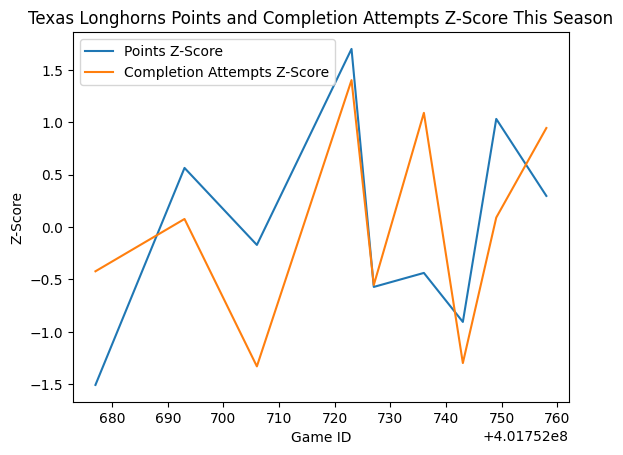

In [8]:
#Analyzing Texas Season Stats To-Date

texas_df = pd.read_csv("game_stats_wide.csv")

season_averages = texas_df[texas_df['team'] == 'Texas']

#Sort by game_id
season_averages = season_averages.sort_values('game_id')

#Z-Score Points & completionAttempts

season_averages['points_z'] = (season_averages['points'] - season_averages['points'].mean()) / season_averages['points'].std()
season_averages['completionAttempts_z'] = (season_averages['completionAttempts'] - season_averages['completionAttempts'].mean()) / season_averages['completionAttempts'].std()

#Plot Z-Score Points and completionAttempts Per Game

plt.plot(season_averages['game_id'], season_averages['points_z'], label='Points Z-Score')
plt.plot(season_averages['game_id'], season_averages['completionAttempts_z'], label='Completion Attempts Z-Score')
plt.xlabel('Game ID')
plt.ylabel('Z-Score')
plt.title('Texas Longhorns Points and Completion Attempts Z-Score This Season')
plt.legend()
plt.show()